In [51]:
#created on 17/04/2026 by James McLoughlin

In [201]:
from pathlib import Path
import rasterio as rio
from rasterio.mask import mask
from rasterio.plot import show
import geopandas as gpd
import matplotlib.pyplot as plt
#import pandas as pd

In [202]:
parent = Path("C:/Users/jj_mc/OneDrive/Documents/GitHub/EGM722-Assessment/Test Data")
dataset = {}

for subfolder in parent.iterdir():
    if subfolder.is_dir() and not subfolder.name.endswith(".tar") and "AOI" not in subfolder.name:
        files = [f.name for f in subfolder.glob("*_SR_B*.TIF")]
        dataset[subfolder.name] = files

#for folder, files in dataset.items():
#    print(folder)
#    for f in files:
#        print(f"  {f}")
#    print()

folders = list(dataset.keys())

In [203]:
#def parse_usgs_filename(filename):
#    parts = filename.split("_")
#    satellite = parts[0]  # LC08
#    pathrow = parts[2]
#    date_raw = parts[3]  # 20130815
#    return(satellite)

In [210]:
def get_satellite_bands(folder, bands):
#    satellite = parse_usgs_filename(filename)
    parts = folder.split("_")
    satellite = parts[0]  # LC08
    if satellite == "LC08":      
        mapping = {
            "BLUE":"B2",
            "GREEN": "B3",
            "RED": "B4",
            "NIR":"B5",
           }
    elif satellite == "LC05":
        mapping = {
            "BLUE":"B1",
            "GREEN":"B2",
            "RED":"B3",
            "NIR":"B4",
            "SWIR1":"B5",
            "SWIR2":"B6",
        }
    return [mapping[b] for b in bands]

In [216]:
NDVI = 1
if NDVI == 1:
    colours = "RED", "NIR"

#downselect files needed for analysis
AnalysisSet = []
for folder in folders:
    satbands = get_satellite_bands(folder,colours)
    for file in dataset[folder]:
        if any(code in file for code in satbands):
            AnalysisSet.append(file)

print(AnalysisSet)

['LC08_L2SP_043034_20130815_20200912_02_T1_SR_B4.TIF', 'LC08_L2SP_043034_20130815_20200912_02_T1_SR_B5.TIF', 'LC08_L2SP_043034_20141106_20200910_02_T1_SR_B4.TIF', 'LC08_L2SP_043034_20141106_20200910_02_T1_SR_B5.TIF']


In [194]:
#import raster data
with rio.open(parent / folders[0] / dataset[folders[0]][0]) as src:
    crs=src.crs

# Import bounary shapefile
boundary = gpd.read_file("C:/Users/jj_mc/OneDrive/Documents/GitHub/EGM722-Assessment/Test Data/AOI/aoi.shp")
# Match CRS
boundary = boundary.to_crs(src.crs)

#fig, ax = plt.subplots(figsize=(10, 10))
#boundary.plot(ax=ax, facecolor = 'none', edgecolor='red', linewidth=2)
#show(data, ax=ax)
#plt.show()

In [213]:
def clipping(folder, bands):
    data = rio.open(parent / folders[0] / dataset[folders[0]][0])
    geom = [feature["geometry"] for feature in boundary.__geo_interface__["features"]]
    out_image, out_transform = mask(data, geom, crop=True)
    data.close()
    
    fig, ax2 = plt.subplots(figsize=(10, 10))
    show(out_image, ax=ax2)

<Axes: >

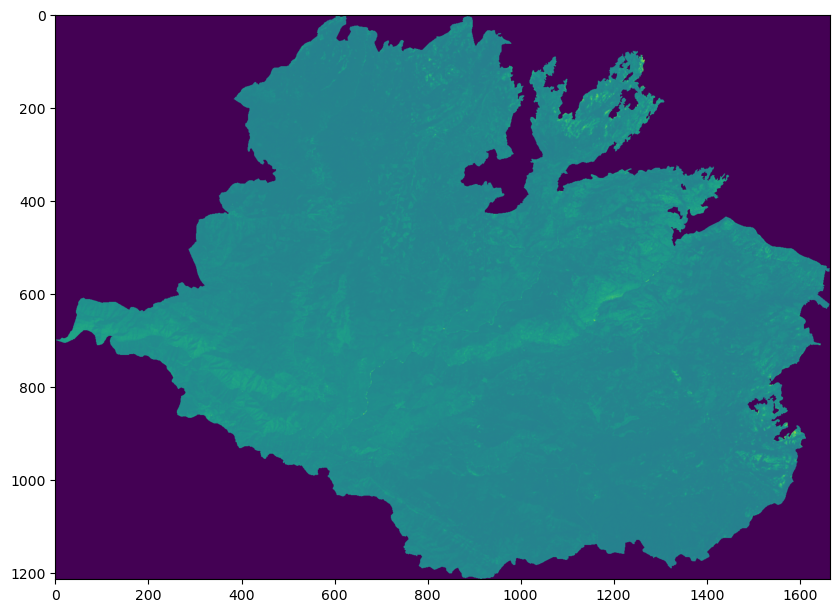

In [195]:
data = rio.open(parent / folders[0] / dataset[folders[0]][0])
geom = [feature["geometry"] for feature in boundary.__geo_interface__["features"]]
out_image, out_transform = mask(data, geom, crop=True)
data.close()

fig, ax2 = plt.subplots(figsize=(10, 10))
show(out_image, ax=ax2)


#    with rio.open(parent / folders[0] / dataset[folders[0]][0]) as data:
#    geom = [feature["geometry"] for feature in boundary.__geo_interface__["features"]]
#    out_image, out_transform = mask(data, geom, crop=True)
#    out_meta = data.meta.copy()
